In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# Nastavení
# ============================================================

BASE_DIR = Path(".")
OUTPUT_DIR = Path("block_prediction_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_SEPARATOR = ";"

FOLDER_PATTERN = "forecast_vs_real_*_h_step_*_days_update_data"


# ============================================================
# Pomocné funkce
# ============================================================

def parse_folder_info(folder: Path):
    """
    Z názvu složky získá délku bloku a počet trénovacích dní.

    Například:
    forecast_vs_real_4_h_step_60_days_update_data
    """
    match = re.search(
        r"forecast_vs_real_(\d+)_h_step_(\d+)_days_update_data",
        folder.name
    )

    if not match:
        return None

    step_hours = int(match.group(1))
    train_days = int(match.group(2))

    train_samples = int((train_days * 24) / step_hours)

    return {
        "step_hours": step_hours,
        "train_days": train_days,
        "train_samples": train_samples,
        "folder": folder.name
    }


def find_column(df, candidates):
    """
    Najde sloupec podle možných názvů.
    """
    lower_cols = {col.lower(): col for col in df.columns}

    for candidate in candidates:
        if candidate.lower() in lower_cols:
            return lower_cols[candidate.lower()]

    raise ValueError(
        f"Nepodařilo se najít sloupec z kandidátů {candidates}. "
        f"Dostupné sloupce: {list(df.columns)}"
    )


def load_single_csv(file: Path, info: dict):
    """
    Načte jeden CSV soubor s predikcí pro konkrétní den.
    """
    df = pd.read_csv(file, sep=CSV_SEPARATOR)

    time_col = find_column(df, ["TimeStamp", "timestamp", "date", "datetime", "day"])
    real_col = find_column(df, ["real", "actual", "real_total", "y_true"])
    forecast_col = find_column(df, ["forecast", "prediction", "forecast_total", "y_pred"])

    df = df[[time_col, real_col, forecast_col]].copy()
    df.columns = ["TimeStamp", "real", "forecast"]

    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])
    df["real"] = pd.to_numeric(df["real"], errors="coerce")
    df["forecast"] = pd.to_numeric(df["forecast"], errors="coerce")

    df = df.dropna(subset=["TimeStamp", "real", "forecast"])

    df["step_hours"] = info["step_hours"]
    df["train_days"] = info["train_days"]
    df["train_samples"] = info["train_samples"]
    df["source_folder"] = info["folder"]
    df["source_file"] = file.name

    return df


def smape(y_true, y_pred):
    """
    Symetrická procentuální chyba.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def compute_metrics(group):
    y_true = group["real"].astype(float)
    y_pred = group["forecast"].astype(float)

    error = y_true - y_pred
    abs_error = np.abs(error)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # relativní metriky
    mean_actual = np.mean(np.abs(y_true))
    total_actual = np.sum(np.abs(y_true))

    nrmse = rmse / mean_actual * 100 if mean_actual != 0 else np.nan
    wape = np.sum(abs_error) / total_actual * 100 if total_actual != 0 else np.nan

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denominator != 0

    smape_value = (
        np.mean(abs_error[smape_mask] / denominator[smape_mask]) * 100
        if smape_mask.sum() > 0
        else np.nan
    )

    # délka bloku je v group stejná
    step_hours = group["step_hours"].iloc[0]

    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "MAE_per_hour": mae / step_hours,
        "RMSE_per_hour": rmse / step_hours,
        "nRMSE_percent": nrmse,
        "WAPE_percent": wape,
        "sMAPE_percent": smape_value,
        "MeanError": error.mean(),
        "MaxError": abs_error.max(),
        "count": len(group)
    })

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# 1. Načtení všech složek a CSV souborů
# ============================================================

all_data_parts = []

folders = sorted(BASE_DIR.glob(FOLDER_PATTERN))

if not folders:
    raise ValueError(
        f"Nebyly nalezeny žádné složky podle vzoru: {FOLDER_PATTERN}"
    )

for folder in folders:
    info = parse_folder_info(folder)

    if info is None:
        continue

    csv_files = sorted(folder.glob("*.csv"))

    if not csv_files:
        print(f"Složka {folder.name} neobsahuje žádné CSV soubory.")
        continue

    for file in csv_files:
        try:
            df_file = load_single_csv(file, info)
            all_data_parts.append(df_file)
        except Exception as e:
            print(f"Soubor {file} se nepodařilo načíst: {e}")

if not all_data_parts:
    raise ValueError("Nepodařilo se načíst žádná data.")

data = pd.concat(all_data_parts, ignore_index=True)

print(f"Načteno {len(data)} řádků z {len(all_data_parts)} CSV souborů.")

display(
    data[["source_folder", "step_hours", "train_days", "train_samples"]]
    .drop_duplicates()
    .sort_values(["step_hours", "train_days"])
)

Načteno 3988 řádků z 322 CSV souborů.


,source_folder,step_hours,train_days,train_samples
2800,forecast_vs_real_1_h_step_7_days_update_data,1,7,168
88,forecast_vs_real_1_h_step_10_days_update_data,1,10,240
352,forecast_vs_real_1_h_step_15_days_update_data,1,15,360
616,forecast_vs_real_1_h_step_20_days_update_data,1,20,480
880,forecast_vs_real_1_h_step_24_days_update_data,1,24,576
1144,forecast_vs_real_1_h_step_25_days_update_data,1,25,600
1408,forecast_vs_real_1_h_step_30_days_update_data,1,30,720
1672,forecast_vs_real_1_h_step_35_days_update_data,1,35,840
1936,forecast_vs_real_1_h_step_40_days_update_data,1,40,960
2200,forecast_vs_real_1_h_step_45_days_update_data,1,45,1080


In [15]:
# ============================================================
# 2. Výpočet metrik
# ============================================================

results = (
    data
    .groupby(["step_hours", "train_days", "train_samples", "source_folder"])
    .apply(compute_metrics)
    .reset_index()
    .sort_values(["step_hours", "RMSE"])
)

display(results)

results.to_csv(
    OUTPUT_DIR / "all_block_model_metrics.csv",
    sep=CSV_SEPARATOR,
    index=False
)

C:\Users\hp\AppData\Local\Temp\ipykernel_24280\1253518362.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_metrics)


,step_hours,train_days,train_samples,source_folder,MAE,RMSE,MAE_per_hour,RMSE_per_hour,nRMSE_percent,WAPE_percent,sMAPE_percent,MeanError,MaxError,count
10,1,50,1200,forecast_vs_real_1_h_step_50_days_update_data,5.174783e+02,7.086322e+02,5.174783e+02,7.086322e+02,2.561632e+01,1.870631e+01,18.687273,-4.633664e+01,2.435171e+03,72.0
9,1,45,1080,forecast_vs_real_1_h_step_45_days_update_data,5.898976e+02,7.949869e+02,5.898976e+02,7.949869e+02,2.356893e+01,1.748866e+01,17.851157,8.365122e+01,3.502858e+03,264.0
8,1,40,960,forecast_vs_real_1_h_step_40_days_update_data,6.052365e+02,8.166914e+02,6.052365e+02,8.166914e+02,2.421240e+01,1.794341e+01,18.200785,5.232275e+01,3.599348e+03,264.0
7,1,35,840,forecast_vs_real_1_h_step_35_days_update_data,6.138495e+02,8.209356e+02,6.138495e+02,8.209356e+02,2.433823e+01,1.819876e+01,18.590588,1.061629e+02,2.966086e+03,264.0
11,1,60,1440,forecast_vs_real_1_h_step_60_days_update_data,6.483289e+02,8.284049e+02,6.483289e+02,8.284049e+02,2.455968e+01,1.922097e+01,19.697507,1.251568e+02,2.543550e+03,264.0
6,1,30,720,forecast_vs_real_1_h_step_30_days_update_data,6.558321e+02,8.475086e+02,6.558321e+02,8.475086e+02,2.512604e+01,1.944342e+01,19.891310,1.806796e+01,3.486247e+03,264.0
5,1,25,600,forecast_vs_real_1_h_step_25_days_update_data,6.495135e+02,8.540950e+02,6.495135e+02,8.540950e+02,2.532131e+01,1.925609e+01,19.609743,4.988439e+01,3.421840e+03,264.0
3,1,20,480,forecast_vs_real_1_h_step_20_days_update_data,6.738878e+02,9.201246e+02,6.738878e+02,9.201246e+02,2.727888e+01,1.997872e+01,20.248543,1.042988e+02,3.785060e+03,264.0
2,1,15,360,forecast_vs_real_1_h_step_15_days_update_data,7.196537e+02,9.838536e+02,7.196537e+02,9.838536e+02,2.916825e+01,2.133554e+01,21.118959,4.656611e+01,4.347259e+03,264.0
1,1,10,240,forecast_vs_real_1_h_step_10_days_update_data,7.100832e+02,9.914752e+02,7.100832e+02,9.914752e+02,2.939421e+01,2.105180e+01,20.807249,2.683991e+01,4.105344e+03,264.0


In [33]:
# ============================================================
# 3. Nejlepší výsledek pro každou délku bloku
# ============================================================

lower = 200
upper = 600

comparable_candidates = results[
    (results["train_samples"] >= lower) &
    (results["train_samples"] <= upper)
].copy()

METRIC_FOR_SELECTION = "WAPE_percent"
# alternativně:
# METRIC_FOR_SELECTION = "sMAPE_percent"
# METRIC_FOR_SELECTION = "nRMSE_percent"

comparable_best_by_block = (
    comparable_candidates
    .sort_values(METRIC_FOR_SELECTION)
    .groupby("step_hours", as_index=False)
    .first()
    .sort_values("step_hours")
)

display(
    comparable_best_by_block[
        [
            "step_hours",
            "train_days",
            "train_samples",
            "MAE",
            "MAE_per_hour",
            "RMSE",
            "RMSE_per_hour",
            "nRMSE_percent",
            "WAPE_percent",
            "sMAPE_percent"
        ]
    ]
)

,step_hours,train_days,train_samples,MAE,MAE_per_hour,RMSE,RMSE_per_hour,nRMSE_percent,WAPE_percent,sMAPE_percent
0,1,25,600,649.513497,649.513497,854.095026,854.095026,25.321309,19.256092,19.609743
1,2,30,360,1051.816231,525.908116,1341.582031,670.791016,19.886905,15.591569,16.296037
2,4,90,540,1961.168193,490.292048,2474.721116,618.680279,18.341981,14.535662,14.888044
3,6,90,360,2696.835673,449.472612,3393.506078,565.584346,16.767849,13.325490,14.051210
4,8,120,360,3301.447540,412.680942,4219.093964,527.386746,15.635406,12.234730,12.347023
5,12,120,240,4109.457842,342.454820,5199.191731,433.265978,12.845013,10.152740,10.371409


In [34]:
latex_table = comparable_best_by_block[
    [
        "step_hours",
        "train_days",
        "train_samples",
        "MAE_per_hour",
        "nRMSE_percent",
        "WAPE_percent",
        "sMAPE_percent"
    ]
].copy()

latex_table = latex_table.rename(columns={
    "step_hours": "Délka bloku [h]",
    "train_days": "Trénovací okno [dny]",
    "train_samples": "Počet historických vzorků",
    "MAE_per_hour": "MAE/h",
    "nRMSE_percent": "nRMSE [\\%]",
    "WAPE_percent": "WAPE [\\%]",
    "sMAPE_percent": "sMAPE [\\%]"
})

print(
    latex_table.to_latex(
        index=False,
        float_format="%.2f",
        escape=False
    )
)

\begin{tabular}{rrrrrrr}
\toprule
Délka bloku [h] & Trénovací okno [dny] & Počet historických vzorků & MAE/h & nRMSE [\%] & WAPE [\%] & sMAPE [\%] \\
\midrule
1 & 25 & 600 & 649.51 & 25.32 & 19.26 & 19.61 \\
2 & 30 & 360 & 525.91 & 19.89 & 15.59 & 16.30 \\
4 & 90 & 540 & 490.29 & 18.34 & 14.54 & 14.89 \\
6 & 90 & 360 & 449.47 & 16.77 & 13.33 & 14.05 \\
8 & 120 & 360 & 412.68 & 15.64 & 12.23 & 12.35 \\
12 & 120 & 240 & 342.45 & 12.85 & 10.15 & 10.37 \\
\bottomrule
\end{tabular}



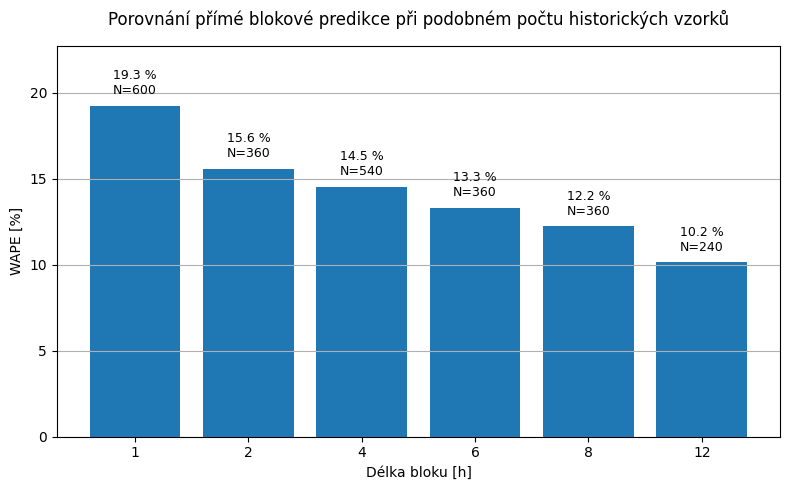

In [35]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparable_best_by_block["step_hours"].astype(str),
    comparable_best_by_block["WAPE_percent"]
)

plt.xlabel("Délka bloku [h]")
plt.ylabel("WAPE [%]")
plt.title(
    "Porovnání přímé blokové predikce při podobném počtu historických vzorků",
    pad=15
)

plt.grid(axis="y")

# horní rezerva pro popisky
max_value = comparable_best_by_block["WAPE_percent"].max()
plt.ylim(0, max_value * 1.18)

for i, row in comparable_best_by_block.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["WAPE_percent"] + max_value * 0.025,
        f'{row["WAPE_percent"]:.1f} %\nN={int(row["train_samples"])}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "comparable_block_prediction_wape.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

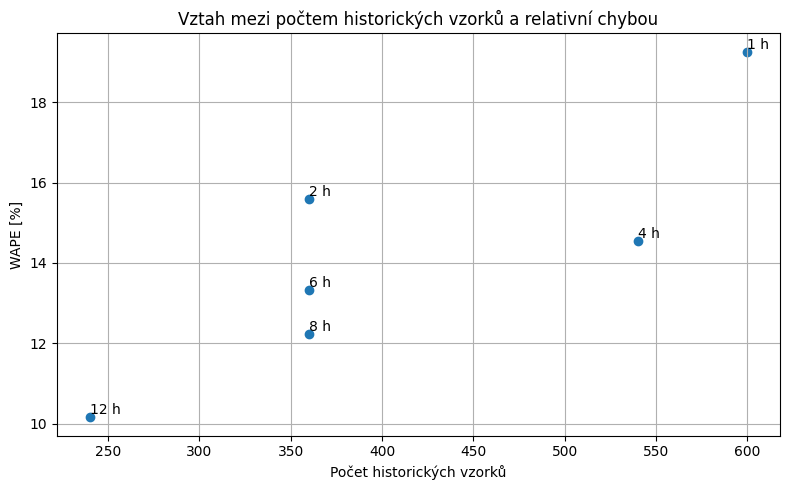

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    comparable_best_by_block["train_samples"],
    comparable_best_by_block["WAPE_percent"]
)

for _, row in comparable_best_by_block.iterrows():
    plt.text(
        row["train_samples"],
        row["WAPE_percent"],
        f'{int(row["step_hours"])} h',
        ha="left",
        va="bottom"
    )

plt.xlabel("Počet historických vzorků")
plt.ylabel("WAPE [%]")
plt.title("Vztah mezi počtem historických vzorků a relativní chybou")
plt.grid(True)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "comparable_samples_vs_wape.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
print("ZÁVĚRY PRO PŘÍMOU BLOKOVOU PREDIKCI:\n")

tested_blocks = ", ".join(
    [f"{int(x)} h" for x in sorted(best_by_block["step_hours"].unique())]
)

print(f"Testované délky bloků: {tested_blocks}.")

best_row = best_by_block.sort_values("RMSE").iloc[0]
worst_row = best_by_block.sort_values("RMSE").iloc[-1]

print(
    f"Nejnižší chyby bylo dosaženo u bloku {int(best_row['step_hours'])} h "
    f"s trénovacím oknem {int(best_row['train_days'])} dní "
    f"a počtem historických vzorků {int(best_row['train_samples'])}. "
    f"Hodnota RMSE byla {best_row['RMSE']:.2f}."
)

print(
    f"Nejvyšší chyba byla pozorována u bloku {int(worst_row['step_hours'])} h, "
    f"kde RMSE dosáhla hodnoty {worst_row['RMSE']:.2f}."
)

print(
    "S rostoucí délkou bloku se obecně snižuje počet historických vzorků, "
    "což může omezovat schopnost modelu zachytit opakující se vzory v datech."
)

ZÁVĚRY PRO PŘÍMOU BLOKOVOU PREDIKCI:

Testované délky bloků: 1 h, 2 h, 4 h, 6 h, 8 h, 12 h.
Nejnižší chyby bylo dosaženo u bloku 1 h s trénovacím oknem 20 dní a počtem historických vzorků 480. Hodnota RMSE byla 920.12.
Nejvyšší chyba byla pozorována u bloku 12 h, kde RMSE dosáhla hodnoty 5199.19.
S rostoucí délkou bloku se obecně snižuje počet historických vzorků, což může omezovat schopnost modelu zachytit opakující se vzory v datech.
